# Day 4 — Feature-map inspection

Inspect activations from the tiny CNN and save feature-map galleries.


## Load the trained tiny CNN

This cell recreates the same tiny CNN architecture used in Day 3, then fills it with the learned weights from `models/tiny_cifar10_cnn.pth`.

`checkpoint["model_state_dict"]` contains the trained layer weights. `net.eval()` switches the model into inspection mode, which is the right mode when we are running images through the model without training it.


In [18]:
from collections.abc import Callable

import torch

from cnn_feature_map_lab.paths import project_path
from cnn_feature_map_lab.tiny_cnn import TinyCifar10Cnn

checkpoint_path = project_path("models", "tiny_cifar10_cnn.pth")
checkpoint = torch.load(checkpoint_path, map_location="cpu")

net = TinyCifar10Cnn()
net.load_state_dict(checkpoint["model_state_dict"])
net.eval()

print(checkpoint.keys())
print(f"mean: {checkpoint['normalize_mean']}")
print(f"std: {checkpoint['normalize_std']}")
net

dict_keys(['model_state_dict', 'optimizer_state_dict', 'batch_size', 'num_workers', 'num_epochs', 'print_every', 'learning_rate', 'momentum', 'normalize_mean', 'normalize_std', 'classes', 'train_loss_history', 'final_train_loss'])
mean: (0.5, 0.5, 0.5)
std: (0.5, 0.5, 0.5)


TinyCifar10Cnn(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## Register hooks for intermediate activations

This cell prepares a dictionary called `activations` and attaches forward hooks to `conv1` and `conv2`.

A forward hook is a small function PyTorch runs when a chosen layer produces its output. Here the hook saves each layer output with `detach().cpu()`, so we keep the activation tensor for inspection without keeping the training graph.


In [19]:
activations: dict[str, torch.Tensor] = {}


def save_activation(name: str) -> Callable:
    def hook(module: torch.nn.Module, inputs: tuple[torch.Tensor, ...], output: torch.Tensor) -> None:
        activations[name] = output.detach().cpu()

    return hook


hooks = [
    net.conv1.register_forward_hook(save_activation("conv1")),
    net.conv2.register_forward_hook(save_activation("conv2")),
]

## Recreate the CIFAR-10 test input pipeline

This cell rebuilds the same image preprocessing recipe that the tiny CNN saw during training.

The transform converts CIFAR-10 images into tensors, scales pixels to floating-point values, and normalizes them with the saved `normalize_mean` and `normalize_std`. The DataLoader then groups examples into a small batch shaped `[batch, channels, height, width]`.


In [20]:
import torchvision
from torchvision.transforms import v2

BATCH_SIZE: int = checkpoint["batch_size"]
NUM_WORKERS: int = checkpoint["num_workers"]
NORMALIZE_MEAN: tuple[float, float, float] = checkpoint["normalize_mean"]
NORMALIZE_STD: tuple[float, float, float] = checkpoint["normalize_std"]

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ]
)

test_set = torchvision.datasets.CIFAR10(
    root=str(project_path("data")),
    train=False,
    download=True,
    transform=transform,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

images, labels = next(iter(test_loader))

print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([4, 3, 32, 32])
labels: torch.Size([4])


## Run one batch and inspect activation shapes

This cell sends one batch of images through the trained CNN.

`outputs` has shape `[batch, 10]`, meaning one row per image and one raw class score for each CIFAR-10 class. The feature maps we want for Day 4 are in `activations["conv1"]` and `activations["conv2"]`, where each channel can be displayed as a small image.


In [21]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = net(images)

print("model output:", outputs.shape)
print("conv1 activation:", activations["conv1"].shape)
print("conv2 activation:", activations["conv2"].shape)

model output: torch.Size([4, 10])
conv1 activation: torch.Size([4, 6, 28, 28])
conv2 activation: torch.Size([4, 16, 10, 10])


## Display the image under test

This cell shows the exact batch image whose feature maps will be displayed next.

The DataLoader gives the model a normalized tensor, so this cell first unnormalizes the image back toward display values in the `0..1` range. Keeping the original image beside the activation grids makes it easier to ask what each feature map is responding to.


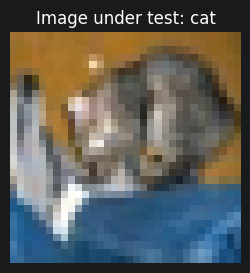

In [22]:
import matplotlib.pyplot as plt

image_index = 0
class_names: tuple[str, ...] = tuple(checkpoint["classes"])

mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
image_to_show = (images[image_index].detach().cpu() * std + mean).clamp(0, 1)
label_name = class_names[labels[image_index].item()]

plt.figure(figsize=(3, 3))
plt.imshow(image_to_show.permute(1, 2, 0).numpy())
plt.title(f"Image under test: {label_name}")
plt.axis("off")
plt.show()

## Save and display feature-map grids

This cell turns selected activation channels into visible feature maps.

Each channel is normalized separately for display, then placed into a Matplotlib grid. `fig.savefig(...)` writes the grid under `outputs/day04_tiny_cnn_activations/`, and `plt.show()` displays the same grid inline in the notebook for immediate inspection.


Saved conv1 feature map grid to C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day04_tiny_cnn_activations\conv1_feature_maps.png


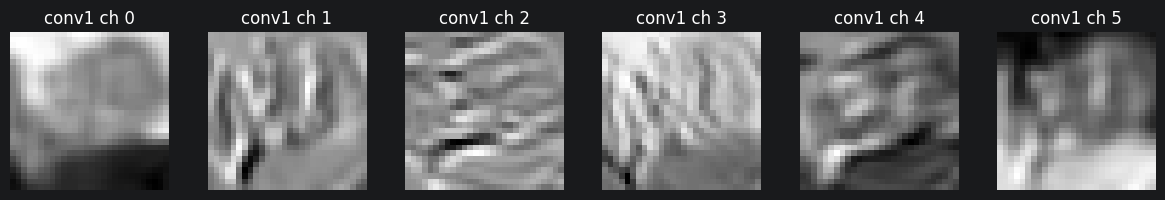

Saved conv2 feature map grid to C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day04_tiny_cnn_activations\conv2_feature_maps.png


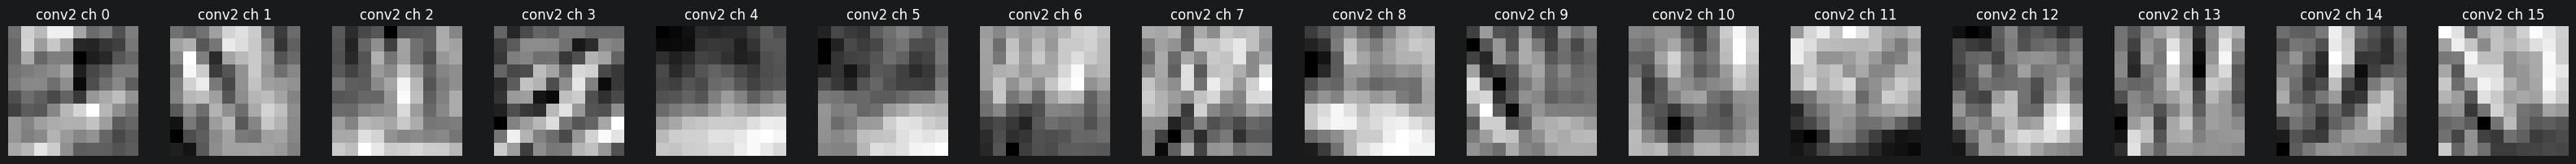

In [23]:
import matplotlib.pyplot as plt

from cnn_feature_map_lab.visualization import normalize_feature_map

OUTPUT_DIR = project_path("outputs", "day04_tiny_cnn_activations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show_feature_map_grid(
    activation: torch.Tensor,
    layer_name: str,
    max_channels: int,
) -> None:
    feature_maps = activation[image_index]
    num_channels = min(max_channels, feature_maps.shape[0])

    fig, axes = plt.subplots(1, num_channels, figsize=(num_channels * 2, 2))

    for channel_index, axis in enumerate(axes):
        feature_map = normalize_feature_map(feature_maps[channel_index])
        axis.imshow(feature_map, cmap="gray")
        axis.set_title(f"{layer_name} ch {channel_index}")
        axis.axis("off")

    output_path = OUTPUT_DIR / f"{layer_name}_feature_maps.png"
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)

    print(f"Saved {layer_name} feature map grid to {output_path}")
    plt.show()
    plt.close(fig)


save_and_show_feature_map_grid(activations["conv1"], "conv1", max_channels=6)
save_and_show_feature_map_grid(activations["conv2"], "conv2", max_channels=16)

## Reflection

Write 3-5 sentences about how early and later activations differ.

Use the phrase **feature map** when describing an individual activation channel or a grid of activation channels.
